In [1]:
import pandas as pd

In [2]:
twitter_data = pd.read_csv("https://raw.githubusercontent.com/prsundaram/datasets/refs/heads/main/twitter_multi_class_sentiment.csv")

In [3]:
display(twitter_data.head())

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [4]:
twitter_data.info()
twitter_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


,0
text,0
label,0
label_name,0


In [5]:
twitter_data['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


## Dataset Analysis

In [6]:
import matplotlib.pyplot as plt

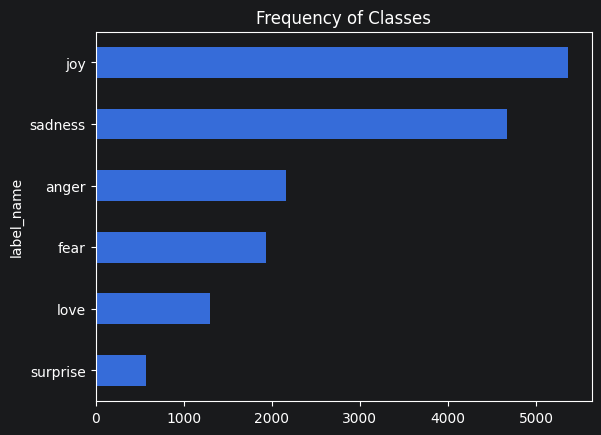

In [7]:
label_counts = twitter_data.label_name.value_counts(ascending=True)
label_counts.plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [8]:
twitter_data['Words per Tweet'] = twitter_data.text.str.split().apply(len)

<Axes: title={'center': 'Words per Tweet'}, xlabel='label_name'>

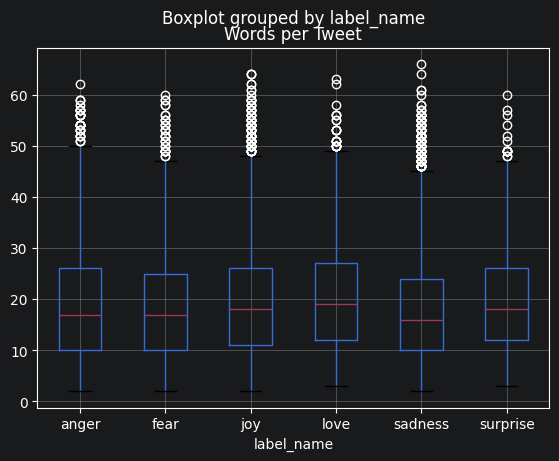

In [9]:
twitter_data.boxplot("Words per Tweet", by="label_name")

## Text to Token conversion

In [10]:
from transformers import AutoTokenizer

In [11]:
model_check_point = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_check_point)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
text = "I love machine learning! Tokenization is awesome"

encoded_text = tokenizer(text)

print(encoded_text)

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 19204, 3989, 2003, 12476, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [13]:
tokenizer.vocab

{'oyster': 21480,
 'responsibilities': 10198,
 'buren': 29470,
 'geological': 9843,
 '##bed': 8270,
 '##ile': 9463,
 'conscious': 9715,
 'matthias': 17885,
 'title': 2516,
 'steep': 9561,
 'kade': 26159,
 'tents': 17732,
 'advocates': 13010,
 'commonplace': 27550,
 '##las': 8523,
 '##uez': 29488,
 '1821': 11723,
 'betting': 19244,
 'aligned': 13115,
 '##llins': 26655,
 'kingdoms': 12028,
 'unpublished': 19106,
 'box': 3482,
 'anchored': 14453,
 'winced': 15574,
 '##erly': 12561,
 'prized': 25695,
 'informing': 21672,
 'fortunately': 14599,
 'features': 2838,
 '##男': 30438,
 '##ch': 2818,
 'pitched': 8219,
 '扌': 1859,
 'library': 3075,
 'grassroots': 23299,
 'cmll': 25395,
 'repaired': 13671,
 'counter': 4675,
 '##9th': 25660,
 'wiley': 18825,
 'swell': 18370,
 'replaces': 20736,
 'daniela': 28541,
 '##ttes': 14581,
 'lush': 16299,
 'garde': 14535,
 'ding': 22033,
 'proceeded': 8979,
 'wit': 15966,
 'guilt': 8056,
 '##後': 30372,
 'hem': 19610,
 'nfc': 22309,
 '##hein': 26496,
 'ᄐ': 1467

## Data Loader and Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(twitter_data, test_size=0.3, random_state=42, stratify=twitter_data['label_name'])

test, validation = train_test_split(test, test_size=1/3, random_state=42, stratify=test['label_name'])

train.shape, test.shape, validation.shape

((11200, 4), (3200, 4), (1600, 4))

In [15]:
from datasets import Dataset, DatasetDict
dataset = DatasetDict(
    {"train": Dataset.from_pandas(train, preserve_index=False),
     "test": Dataset.from_pandas(test, preserve_index=False),
     "validation": Dataset.from_pandas(validation, preserve_index=False)}
)

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 1600
    })
})

## Tokenization of the Emotion/Sentiment Data

In [16]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

print(tokenize(dataset["train"][:2]))

{'input_ids': [[101, 1045, 2514, 12511, 2009, 2003, 2053, 2393, 2005, 2033, 2008, 2060, 5381, 2360, 2008, 1045, 2572, 3407, 2129, 2172, 3606, 2045, 2089, 2022, 1999, 2009, 102], [101, 1045, 2001, 3110, 9191, 2043, 1045, 4149, 2009, 1998, 4415, 2043, 1045, 2001, 2725, 2026, 5789, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]]}


In [17]:
emotion_encoded = dataset.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [18]:
emotion_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
})

In [19]:
#lable2Id, id2Label

label2id = {x['label_name']:x['label'] for x in dataset["train"]}

id2label = {v:k for k,v in label2id.items()}


In [20]:
label2id, id2label

({'sadness': 0, 'joy': 1, 'fear': 4, 'surprise': 5, 'anger': 3, 'love': 2},
 {0: 'sadness', 1: 'joy', 4: 'fear', 5: 'surprise', 3: 'anger', 2: 'love'})

## Model Building

In [21]:
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(model_check_point)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [23]:
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

## Fine-Tuning Transfomers

In [24]:
from transformers import AutoModelForSequenceClassification, AutoConfig

number_of_labels = len(label2id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = AutoConfig.from_pretrained(model_check_point, label2id=label2id, id2label=id2label)
model = AutoModelForSequenceClassification.from_pretrained(model_check_point, config=config).to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [27]:
from transformers import TrainingArguments

training_dir = "bert_base_training_dir"
training_args = TrainingArguments(
    output_dir=training_dir,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True   # if using GPU
)

In [29]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [30]:
import evaluate
accuracy = evaluate.load('accuracy')

In [31]:
from sklearn.metrics import accuracy_score,f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1}

## Build Model and Trainer

In [32]:
from transformers import Trainer
trainer = Trainer(model=model, args=training_args, compute_metrics=compute_metrics, train_dataset=emotion_encoded['train'], eval_dataset=emotion_encoded['validation'])
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.399242,0.270468,0.916250,0.916366
2,0.200332,0.185718,0.926875,0.927788


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=700, training_loss=0.5550578539712089, metrics={'train_runtime': 134.5509, 'train_samples_per_second': 166.48, 'train_steps_per_second': 5.202, 'total_flos': 1001502421516800.0, 'train_loss': 0.5550578539712089, 'epoch': 2.0})

## Model Evaluation

In [33]:
preds_output = trainer.predict(emotion_encoded['test'])

preds_output.metrics

{'test_loss': 0.20439361035823822,
 'test_accuracy': 0.924375,
 'test_f1': 0.9250501069626423,
 'test_runtime': 3.8931,
 'test_samples_per_second': 821.968,
 'test_steps_per_second': 25.687}

In [37]:
import numpy as np
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = emotion_encoded['test'][:]['label']

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       933
           1       0.96      0.92      0.94      1072
           2       0.80      0.90      0.84       261
           3       0.95      0.91      0.93       432
           4       0.89      0.91      0.90       387
           5       0.77      0.83      0.80       115

    accuracy                           0.92      3200
   macro avg       0.89      0.90      0.89      3200
weighted avg       0.93      0.92      0.93      3200



In [39]:
label2id

{'sadness': 0, 'joy': 1, 'fear': 4, 'surprise': 5, 'anger': 3, 'love': 2}

## Confusion Matrix

In [40]:
import seaborn as sns
from sklearn.metrics import confusion_matrix as cm

cm = cm(y_true, y_pred)
cm

array([[897,  10,   2,  15,   7,   2],
       [ 16, 986,  57,   2,   4,   7],
       [  3,  24, 234,   0,   0,   0],
       [ 20,   2,   1, 393,  16,   0],
       [  8,   2,   0,   5, 353,  19],
       [  0,   3,   0,   0,  17,  95]])

Text(0.5, 80.7222222222222, 'Predicted')

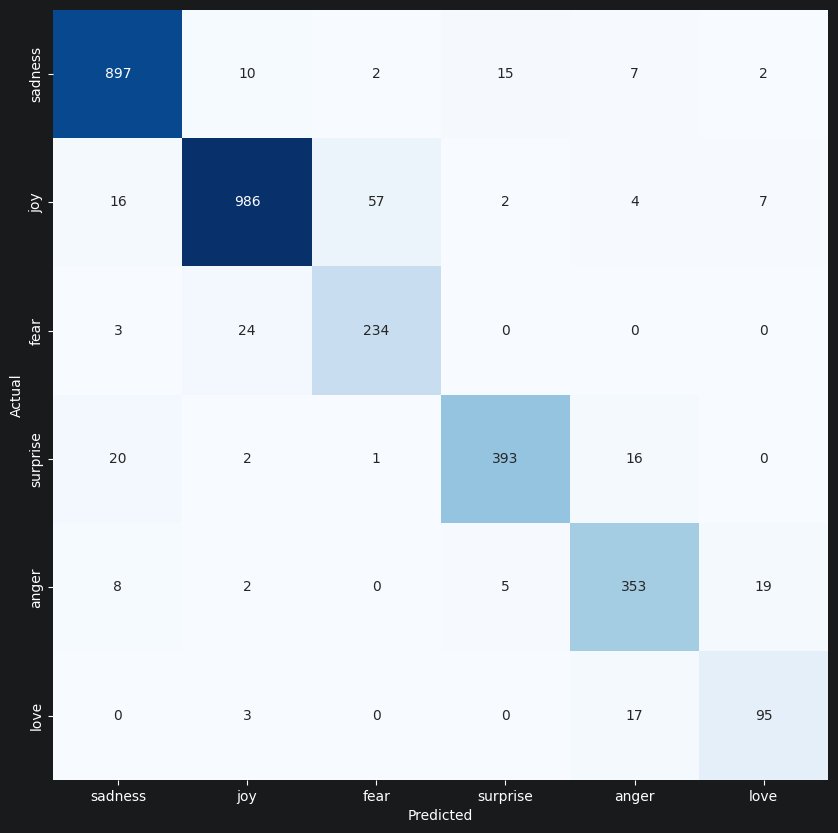

In [47]:
labels = list(label2id.keys())

plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, xticklabels=labels, yticklabels=labels, fmt='d', cbar=False, cmap="Blues")
plt.ylabel("Actual")
plt.xlabel("Predicted")

## 🔍 Confusion Matrix Analysis

The confusion matrix provides a detailed view of how well the model is performing across each sentiment class.

### ✅ Overall Performance
- The model achieves **~92% accuracy**, indicating strong overall performance.
- Most predictions lie along the **diagonal**, which means correct classifications are dominant.

---

### 📊 Class-wise Insights

#### 😢 Sadness
- Correct predictions: **897**
- Minor confusion with:
  - Surprise (15)
  - Joy (10)
- 👉 Very strong performance

---

#### 😊 Joy
- Correct predictions: **986**
- Notable confusion with:
  - Fear (57)
- 👉 Model slightly struggles distinguishing joy vs fear

---

#### 😨 Fear
- Correct predictions: **234**
- Confused with:
  - Joy (24)
- 👉 Moderate performance due to class overlap

---

#### 😲 Surprise
- Correct predictions: **393**
- Confused with:
  - Sadness (20)
  - Anger (16)
- 👉 Some emotional ambiguity

---

#### 😡 Anger
- Correct predictions: **353**
- Confused with:
  - Love (19)
- 👉 Good performance with slight overlap

---

#### ❤️ Love
- Correct predictions: **95**
- Confused with:
  - Anger (17)
- 👉 Weakest class (likely due to fewer samples)

---

### ⚠️ Key Observations

- **Class imbalance** is visible (e.g., Love has fewer samples)
- Some emotions are **semantically close**:
  - Joy ↔ Fear
  - Anger ↔ Love
  - Sadness ↔ Surprise

---

### 🚀 Improvements to Consider

- Apply **class weighting** to handle imbalance
- Use **data augmentation** for low-frequency classes (e.g., Love)
- Try **larger models (BERT-large / RoBERTa)**
- Perform **error analysis on confused pairs**

---

### 💯 Conclusion

The model performs well overall, with strong classification on dominant classes.
Most errors arise from **emotion overlap and class imbalance**, which can be improved with better data strategies.

## Build Function and Store Model

In [51]:
def get_prediction(input_text):
    input_encode = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**input_encode)

        logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()
    return id2label[pred]

In [50]:
test_sentences = [
    "I feel completely broken and lost today",
    "Nothing seems to go right in my life",
    "This is the happiest moment of my life!",
    "I am so excited and grateful for everything",
    "I am terrified about what will happen next",
    "This situation is making me really anxious",
    "Wow I did not expect that at all!",
    "That was a shocking twist!",
    "I am so frustrated and angry right now",
    "This is absolutely unacceptable behavior",
    "I truly love you from the bottom of my heart",
    "You mean everything to me",

    # 🔀 Mixed / tricky cases
    "I am happy but also a little scared",
    "I love this but it makes me nervous",
    "I did not expect this but I like it",
    "I am angry but I still care about you"
]

In [52]:
for text in test_sentences:
    print(f"Text: {text}")
    print(f"Prediction: {get_prediction(text)}")
    print("-" * 50)

Text: I feel completely broken and lost today
Prediction: sadness
--------------------------------------------------
Text: Nothing seems to go right in my life
Prediction: joy
--------------------------------------------------
Text: This is the happiest moment of my life!
Prediction: joy
--------------------------------------------------
Text: I am so excited and grateful for everything
Prediction: joy
--------------------------------------------------
Text: I am terrified about what will happen next
Prediction: fear
--------------------------------------------------
Text: This situation is making me really anxious
Prediction: fear
--------------------------------------------------
Text: Wow I did not expect that at all!
Prediction: surprise
--------------------------------------------------
Text: That was a shocking twist!
Prediction: surprise
--------------------------------------------------
Text: I am so frustrated and angry right now
Prediction: anger
-----------------------------

In [53]:
trainer.save_model("bert-base-uncased-sentiment-hugging-face")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Use Pipeline for Predection

In [55]:
from transformers import pipeline

classifier = pipeline('text-classification', model="bert-base-uncased-sentiment-hugging-face")

for text in test_sentences:
    print(f"Text: {text}")
    print(f"Prediction: {classifier(text)}")
    print("-" * 50)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Text: I feel completely broken and lost today
Prediction: [{'label': 'fear', 'score': 0.37232986092567444}]
--------------------------------------------------
Text: Nothing seems to go right in my life
Prediction: [{'label': 'fear', 'score': 0.3813794255256653}]
--------------------------------------------------
Text: This is the happiest moment of my life!
Prediction: [{'label': 'fear', 'score': 0.3818511962890625}]
--------------------------------------------------
Text: I am so excited and grateful for everything
Prediction: [{'label': 'fear', 'score': 0.3813794255256653}]
--------------------------------------------------
Text: I am terrified about what will happen next
Prediction: [{'label': 'fear', 'score': 0.3813794255256653}]
--------------------------------------------------
Text: This situation is making me really anxious


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Prediction: [{'label': 'fear', 'score': 0.37232986092567444}]
--------------------------------------------------
Text: Wow I did not expect that at all!
Prediction: [{'label': 'fear', 'score': 0.3818511962890625}]
--------------------------------------------------
Text: That was a shocking twist!
Prediction: [{'label': 'fear', 'score': 0.3528299629688263}]
--------------------------------------------------
Text: I am so frustrated and angry right now
Prediction: [{'label': 'fear', 'score': 0.3813794255256653}]
--------------------------------------------------
Text: This is absolutely unacceptable behavior
Prediction: [{'label': 'fear', 'score': 0.3605528771877289}]
--------------------------------------------------
Text: I truly love you from the bottom of my heart
Prediction: [{'label': 'fear', 'score': 0.3980306386947632}]
--------------------------------------------------
Text: You mean everything to me
Prediction: [{'label': 'fear', 'score': 0.3605528771877289}]
------------------